### Data Ingestion from DOSM for parliament income and population data, preprocessing and feature engineering

In [ ]:
import pandas as pd
import requests

In [2]:
URL_DATA = 'https://storage.dosm.gov.my/population/population_state.parquet'

population = pd.read_parquet(URL_DATA)
if 'date' in population.columns: population['date'] = pd.to_datetime(population['date'])

In [3]:
population.head()

,state,date,sex,age,ethnicity,population
0,Johor,1970-01-01,both,overall,overall,1325.6
1,Johor,1970-01-01,both,0-4,overall,210.1
2,Johor,1970-01-01,both,5-9,overall,215.7
3,Johor,1970-01-01,both,10-14,overall,192.2
4,Johor,1970-01-01,both,15-19,overall,152.8


In [4]:
pop = population[(population['state'] == 'W.P. Kuala Lumpur') &
           (population['sex'] == 'both') &
           (population['age'] == 'overall') &
           (population['ethnicity'] == 'overall')].reset_index(drop=True)
pop.head()

,state,date,sex,age,ethnicity,population
0,W.P. Kuala Lumpur,1980-01-01,both,overall,overall,982.9
1,W.P. Kuala Lumpur,1981-01-01,both,overall,overall,1006.1
2,W.P. Kuala Lumpur,1982-01-01,both,overall,overall,1028.5
3,W.P. Kuala Lumpur,1983-01-01,both,overall,overall,1050.7
4,W.P. Kuala Lumpur,1984-01-01,both,overall,overall,1072.2


In [5]:
index = pop[pop['date'] == '2022-01-01'].index.values[0]
pop_kl = pop.loc[index:].drop(columns=['state', 'sex', 'age', 'ethnicity']).reset_index(drop=True)
pop_kl['date'] = pd.to_datetime(pop_kl['date'])
pop_kl

,date,population
0,2022-01-01,1961.2
1,2023-01-01,2005.7
2,2024-01-01,2067.5
3,2025-01-01,2074.1


In [6]:
pop_kl['population_increase'] = pop_kl['population'].pct_change()
pop_kl['population_increase_cum'] = (1+pop_kl['population_increase']).cumprod()
pop_kl.rename(columns={'population':'population_kl'}, inplace=True)
pop_kl.dropna(inplace=True)
pop_kl

,date,population_kl,population_increase,population_increase_cum
1,2023-01-01,2005.7,0.022690,1.022690
2,2024-01-01,2067.5,0.030812,1.054202
3,2025-01-01,2074.1,0.003192,1.057567


In [8]:
URL_DATA = 'https://storage.dosm.gov.my/population/population_parlimen.parquet'
df = pd.read_parquet(URL_DATA)
if 'date' in df.columns: df['date'] = pd.to_datetime(df['date'])

In [9]:
df.head()

,date,state,parlimen,sex,age,ethnicity,population
0,2020-01-01,Perlis,P.001 Padang Besar,both,overall,overall,86.798
1,2020-01-01,Perlis,P.001 Padang Besar,both,overall,citizen,84.074
2,2020-01-01,Perlis,P.001 Padang Besar,both,overall,noncitizen,2.724
3,2020-01-01,Perlis,P.001 Padang Besar,female,overall,overall,42.311
4,2020-01-01,Perlis,P.001 Padang Besar,male,overall,overall,44.487


In [10]:
pop_parlimen = df[(df['state'] == 'W.P. Kuala Lumpur') &
                  (df['sex'] == 'both') &
                  (df['age'] == 'overall') &
                  (df['ethnicity'] == 'overall')].reset_index(drop=True)
pop_parlimen.head()

,date,state,parlimen,sex,age,ethnicity,population
0,2020-01-01,W.P. Kuala Lumpur,P.114 Kepong,both,overall,overall,106.199
1,2021-01-01,W.P. Kuala Lumpur,P.114 Kepong,both,overall,overall,105.200
2,2022-01-01,W.P. Kuala Lumpur,P.114 Kepong,both,overall,overall,104.200
3,2020-01-01,W.P. Kuala Lumpur,P.115 Batu,both,overall,overall,219.132
4,2021-01-01,W.P. Kuala Lumpur,P.115 Batu,both,overall,overall,217.100


In [11]:
pop_parlimen.drop(columns=['state', 'sex', 'age', 'ethnicity'], inplace=True)
pop_parlimen.head()

,date,parlimen,population
0,2020-01-01,P.114 Kepong,106.199
1,2021-01-01,P.114 Kepong,105.200
2,2022-01-01,P.114 Kepong,104.200
3,2020-01-01,P.115 Batu,219.132
4,2021-01-01,P.115 Batu,217.100


In [12]:
parlimen = pop_parlimen['parlimen'].unique()
dates = pd.to_datetime(['2023-01-01', '2024-01-01', '2025-01-01'])
for ob in parlimen:
    dataframe = pd.DataFrame({'date': dates})
    dataframe['parlimen'] = ob
    pop_parlimen = pd.concat([pop_parlimen, dataframe], ignore_index=True)

In [13]:
pop_parlimen = pop_parlimen.sort_values(['parlimen', 'date']).reset_index(drop=True)
pop_parlimen.head()

,date,parlimen,population
0,2020-01-01,P.114 Kepong,106.199
1,2021-01-01,P.114 Kepong,105.200
2,2022-01-01,P.114 Kepong,104.200
3,2023-01-01,P.114 Kepong,NaN
4,2024-01-01,P.114 Kepong,NaN


In [14]:
merged = pop_parlimen.merge(pop_kl, on='date', how='outer')
index_date = merged[merged['date'] == '2022-01-01'].index.values[0]
merged = merged.loc[index_date:].reset_index(drop=True)
merged.head()

,date,parlimen,population,population_kl,population_increase,population_increase_cum
0,2022-01-01,P.114 Kepong,104.2,NaN,NaN,NaN
1,2022-01-01,P.115 Batu,215.1,NaN,NaN,NaN
2,2022-01-01,P.116 Wangsa Maju,211.6,NaN,NaN,NaN
3,2022-01-01,P.117 Segambut,249.0,NaN,NaN,NaN
4,2022-01-01,P.118 Setiawangsa,144.4,NaN,NaN,NaN


In [15]:
# A faster, more 'Pandas-native' way
merged['population'] = merged.groupby('parlimen')['population'].ffill() * \
                       merged['population_increase_cum'].fillna(1)
merged

,date,parlimen,population,population_kl,population_increase,population_increase_cum
0,2022-01-01,P.114 Kepong,104.200000,NaN,NaN,NaN
1,2022-01-01,P.115 Batu,215.100000,NaN,NaN,NaN
2,2022-01-01,P.116 Wangsa Maju,211.600000,NaN,NaN,NaN
3,2022-01-01,P.117 Segambut,249.000000,NaN,NaN,NaN
4,2022-01-01,P.118 Setiawangsa,144.400000,NaN,NaN,NaN
5,2022-01-01,P.119 Titiwangsa,119.800000,NaN,NaN,NaN
6,2022-01-01,P.120 Bukit Bintang,118.300000,NaN,NaN,NaN
7,2022-01-01,P.121 Lembah Pantai,145.300000,NaN,NaN,NaN
8,2022-01-01,P.122 Seputeh,316.500000,NaN,NaN,NaN
9,2022-01-01,P.123 Cheras,133.300000,NaN,NaN,NaN


In [16]:
pop_parlimen = merged.sort_values(by=['parlimen', 'date']).reset_index(drop=True)
pop_parlimen.drop(columns=['population_kl', 'population_increase', 'population_increase_cum'], inplace=True)
pop_parlimen

,date,parlimen,population
0,2022-01-01,P.114 Kepong,104.200000
1,2023-01-01,P.114 Kepong,106.564318
2,2024-01-01,P.114 Kepong,109.847797
3,2025-01-01,P.114 Kepong,110.198460
4,2022-01-01,P.115 Batu,215.100000
5,2023-01-01,P.115 Batu,219.980660
6,2024-01-01,P.115 Batu,226.758745
7,2025-01-01,P.115 Batu,227.482618
8,2022-01-01,P.116 Wangsa Maju,211.600000
9,2023-01-01,P.116 Wangsa Maju,216.401244


In [17]:
income = requests.get("https://api.data.gov.my/data-catalogue?id=hh_income_parlimen").json()
income

[{'date': '2019-01-01',
  'state': 'Perlis',
  'parlimen': 'P.001 Padang Besar',
  'income_mean': 4747,
  'income_median': 4075},
 {'date': '2022-01-01',
  'state': 'Perlis',
  'parlimen': 'P.001 Padang Besar',
  'income_mean': 4984,
  'income_median': 4389},
 {'date': '2024-01-01',
  'state': 'Perlis',
  'parlimen': 'P.001 Padang Besar',
  'income_mean': 5792,
  'income_median': 4818},
 {'date': '2019-01-01',
  'state': 'Perlis',
  'parlimen': 'P.002 Kangar',
  'income_mean': 5899,
  'income_median': 4889},
 {'date': '2022-01-01',
  'state': 'Perlis',
  'parlimen': 'P.002 Kangar',
  'income_mean': 6167,
  'income_median': 4998},
 {'date': '2024-01-01',
  'state': 'Perlis',
  'parlimen': 'P.002 Kangar',
  'income_mean': 6216,
  'income_median': 5093},
 {'date': '2019-01-01',
  'state': 'Perlis',
  'parlimen': 'P.003 Arau',
  'income_mean': 5411,
  'income_median': 4594},
 {'date': '2022-01-01',
  'state': 'Perlis',
  'parlimen': 'P.003 Arau',
  'income_mean': 5723,
  'income_median': 4

In [18]:
ls = []

for item in income:
    if item.get('state') == 'W.P. Kuala Lumpur':
        ls.append(item)

In [19]:
income = pd.DataFrame(ls)
if 'date' in income.columns: income['date'] = pd.to_datetime(income['date'])
income.head()

,date,state,parlimen,income_mean,income_median
0,2019-01-01,W.P. Kuala Lumpur,P.114 Kepong,13087,11274
1,2022-01-01,W.P. Kuala Lumpur,P.114 Kepong,12085,10412
2,2024-01-01,W.P. Kuala Lumpur,P.114 Kepong,14723,10570
3,2019-01-01,W.P. Kuala Lumpur,P.115 Batu,11019,9426
4,2022-01-01,W.P. Kuala Lumpur,P.115 Batu,10136,8618


In [20]:
income_par = income.drop('state', axis=1).sort_values(by=['parlimen', 'date'])
income_par

,date,parlimen,income_mean,income_median
0,2019-01-01,P.114 Kepong,13087,11274
1,2022-01-01,P.114 Kepong,12085,10412
2,2024-01-01,P.114 Kepong,14723,10570
3,2019-01-01,P.115 Batu,11019,9426
4,2022-01-01,P.115 Batu,10136,8618
5,2024-01-01,P.115 Batu,11445,9929
6,2019-01-01,P.116 Wangsa Maju,11153,9716
7,2022-01-01,P.116 Wangsa Maju,11304,9593
8,2024-01-01,P.116 Wangsa Maju,12276,9974
9,2019-01-01,P.117 Segambut,20521,15342


In [21]:
parlimen = income_par['parlimen'].unique()
dates = pd.to_datetime(['2020-01-01', '2021-01-01', '2023-01-01', '2025-01-01'])
for ob in parlimen:
    dataframe = pd.DataFrame({'date': dates})
    dataframe['parlimen'] = ob
    income_par = pd.concat([income_par, dataframe], ignore_index=True)

income_par = income_par.sort_values(['parlimen', 'date']).reset_index(drop=True)
income_par.set_index(['parlimen', 'date'])[:10]

income_mean  income_median
parlimen     date                                  
P.114 Kepong 2019-01-01      13087.0        11274.0
             2020-01-01          NaN            NaN
             2021-01-01          NaN            NaN
             2022-01-01      12085.0        10412.0
             2023-01-01          NaN            NaN
             2024-01-01      14723.0        10570.0
             2025-01-01          NaN            NaN
P.115 Batu   2019-01-01      11019.0         9426.0
             2020-01-01          NaN            NaN
             2021-01-01          NaN            NaN

In [22]:
income_avg = income_par.reset_index().groupby('parlimen').mean(numeric_only=True)
income_avg

,index,income_mean,income_median
parlimen,,,
P.114 Kepong,3.0,13298.333333,10752.000000
P.115 Batu,10.0,10866.666667,9324.333333
P.116 Wangsa Maju,17.0,11577.666667,9761.000000
P.117 Segambut,24.0,21613.666667,15033.333333
P.118 Setiawangsa,31.0,14088.666667,10011.000000
P.119 Titiwangsa,38.0,12666.333333,10304.666667
P.120 Bukit Bintang,45.0,14543.000000,11169.000000
P.121 Lembah Pantai,52.0,12960.000000,9937.333333
P.122 Seputeh,59.0,12983.333333,11133.333333


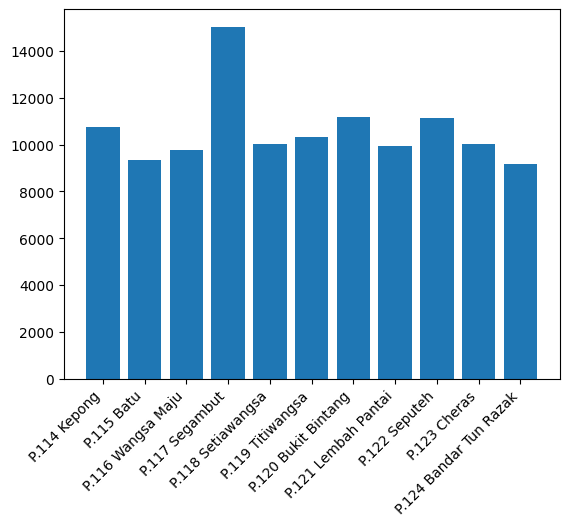

In [23]:
import matplotlib.pyplot as plt

plt.bar(income_avg.index, income_avg['income_median'])
plt.xticks(rotation=45, ha='right')
plt.show()

In [24]:
merged2 = income_par.merge(pop_parlimen, on=['parlimen', 'date'], how='outer')
merged2[:10]

,date,parlimen,income_mean,income_median,population
0,2019-01-01,P.114 Kepong,13087.0,11274.0,NaN
1,2020-01-01,P.114 Kepong,NaN,NaN,NaN
2,2021-01-01,P.114 Kepong,NaN,NaN,NaN
3,2022-01-01,P.114 Kepong,12085.0,10412.0,104.200000
4,2023-01-01,P.114 Kepong,NaN,NaN,106.564318
5,2024-01-01,P.114 Kepong,14723.0,10570.0,109.847797
6,2025-01-01,P.114 Kepong,NaN,NaN,110.198460
7,2019-01-01,P.115 Batu,11019.0,9426.0,NaN
8,2020-01-01,P.115 Batu,NaN,NaN,NaN
9,2021-01-01,P.115 Batu,NaN,NaN,NaN


In [25]:
merged2[['income_mean', 'income_median']] = (
    merged2.groupby('parlimen')[['income_mean', 'income_median']]
    .transform(lambda x: x.interpolate()))
merged2[:20]

,date,parlimen,income_mean,income_median,population
0,2019-01-01,P.114 Kepong,13087.000000,11274.000000,NaN
1,2020-01-01,P.114 Kepong,12753.000000,10986.666667,NaN
2,2021-01-01,P.114 Kepong,12419.000000,10699.333333,NaN
3,2022-01-01,P.114 Kepong,12085.000000,10412.000000,104.200000
4,2023-01-01,P.114 Kepong,13404.000000,10491.000000,106.564318
5,2024-01-01,P.114 Kepong,14723.000000,10570.000000,109.847797
6,2025-01-01,P.114 Kepong,14723.000000,10570.000000,110.198460
7,2019-01-01,P.115 Batu,11019.000000,9426.000000,NaN
8,2020-01-01,P.115 Batu,10724.666667,9156.666667,NaN
9,2021-01-01,P.115 Batu,10430.333333,8887.333333,NaN


In [26]:
income_population = merged2[~merged2['date'].dt.year.isin([2019, 2020])].reset_index(drop=True)
income_population[:10]

,date,parlimen,income_mean,income_median,population
0,2021-01-01,P.114 Kepong,12419.000000,10699.333333,NaN
1,2022-01-01,P.114 Kepong,12085.000000,10412.000000,104.200000
2,2023-01-01,P.114 Kepong,13404.000000,10491.000000,106.564318
3,2024-01-01,P.114 Kepong,14723.000000,10570.000000,109.847797
4,2025-01-01,P.114 Kepong,14723.000000,10570.000000,110.198460
5,2021-01-01,P.115 Batu,10430.333333,8887.333333,NaN
6,2022-01-01,P.115 Batu,10136.000000,8618.000000,215.100000
7,2023-01-01,P.115 Batu,10790.500000,9273.500000,219.980660
8,2024-01-01,P.115 Batu,11445.000000,9929.000000,226.758745
9,2025-01-01,P.115 Batu,11445.000000,9929.000000,227.482618


In [27]:
income_population['population'] = income_population.groupby('parlimen')['population'].bfill()
income_population[:10]

,date,parlimen,income_mean,income_median,population
0,2021-01-01,P.114 Kepong,12419.000000,10699.333333,104.200000
1,2022-01-01,P.114 Kepong,12085.000000,10412.000000,104.200000
2,2023-01-01,P.114 Kepong,13404.000000,10491.000000,106.564318
3,2024-01-01,P.114 Kepong,14723.000000,10570.000000,109.847797
4,2025-01-01,P.114 Kepong,14723.000000,10570.000000,110.198460
5,2021-01-01,P.115 Batu,10430.333333,8887.333333,215.100000
6,2022-01-01,P.115 Batu,10136.000000,8618.000000,215.100000
7,2023-01-01,P.115 Batu,10790.500000,9273.500000,219.980660
8,2024-01-01,P.115 Batu,11445.000000,9929.000000,226.758745
9,2025-01-01,P.115 Batu,11445.000000,9929.000000,227.482618


In [28]:
income_population.isna().sum()

date             0
parlimen         0
income_mean      0
income_median    0
population       0
dtype: int64

In [ ]:
# income_population.to_csv("data/income_population.csv", index=False)